# Spark Cognition: Challenge

<div style="text-align:justify">
You are working for SparkCognition as a Data Scientist. SparkCognition has been commissioned by an insurance company to develop a tool to optimize their marketing efforts. They have given us a data set as a result of an email marketing campaign. The data set includes customer information, described below, as a well as whether the customer responded to the marketing campaign or not.
</div>

## Load Packages

In [1]:
import warnings, seaborn, pandas, numpy

from matplotlib import pyplot

from imblearn.over_sampling import RandomOverSampler

from scipy.stats import skew

from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold

%matplotlib inline

## DataViz Configuration

In [2]:
pyplot.rcParams['figure.figsize'] = (15, 7)
warnings.filterwarnings('ignore')

## Fetch Train Dataset

In [3]:
df = pandas.read_csv('marketing_training.csv')
df.head(5)

,custAge,profession,marital,schooling,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pmonths,pastEmail,responded
0,55.0,admin.,single,university.degree,unknown,no,no,cellular,nov,mon,...,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,999.0,0,no
1,NaN,blue-collar,married,NaN,no,no,no,cellular,jul,mon,...,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,999.0,0,no
2,42.0,technician,married,high.school,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,999.0,0,no
3,55.0,management,divorced,NaN,unknown,yes,yes,cellular,jul,wed,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,999.0,0,no
4,NaN,admin.,divorced,university.degree,no,yes,no,cellular,may,tue,...,1,failure,-1.8,92.893,-46.2,1.291,5099.1,999.0,1,no


## Empty Indicators - Categorical Columns

In [4]:
def empty_indicator(df):
    # TODO
    df['not_prev_cont'] = df['pmonths'].apply(lambda x : 1 if x == 999 else 0)
    
    # TODO
    df['is_empty_day'] = 0
    df.loc[df['day_of_week'].isna(), 'is_empty_day'] = 1
    
    return df

df = empty_indicator(df)

## Dataset Distribution - Imbalanced Labels

In [5]:
df['responded'].value_counts()

no     6574
yes     840
Name: responded, dtype: int64

## Column Types

In [6]:
categorical_cols = [
    'profession', 'marital', 'schooling', 'default', 'housing',
    'loan', 'month', 'day_of_week', 'poutcome', 'contact'
]

binary_cols = ['not_prev_cont', 'is_empty_day']

remove = ['responded']
numerical_cols = set(df.columns) - (set(categorical_cols + binary_cols + remove))
print(numerical_cols)

{'emp.var.rate', 'pmonths', 'cons.conf.idx', 'custAge', 'previous', 'campaign', 'nr.employed', 'euribor3m', 'pdays', 'cons.price.idx', 'pastEmail'}


## Correlation Plot

<AxesSubplot:>

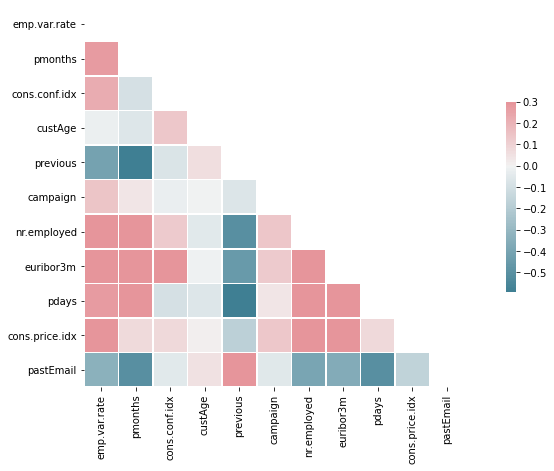

In [7]:
cr = df[numerical_cols].corr()

mk = numpy.zeros_like(cr, dtype=numpy.bool)
mk[numpy.triu_indices_from(mk)] = True
cm = seaborn.diverging_palette(220, 10, as_cmap=True)
cbar_kws={"shrink":.5}

seaborn.heatmap(cr,mask=mk,cmap=cm,vmax=.3,center=0,square=True,linewidths=.5,cbar_kws=cbar_kws)

## Missing Values

In [8]:
df.isnull().sum()

custAge           1804
profession           0
marital              0
schooling         2155
default              0
housing              0
loan                 0
contact              0
month                0
day_of_week        711
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
pmonths              0
pastEmail            0
responded            0
not_prev_cont        0
is_empty_day         0
dtype: int64

## Customer Age

### Sample Skewness

Skewness Rate: 0.8791224890512763


[]

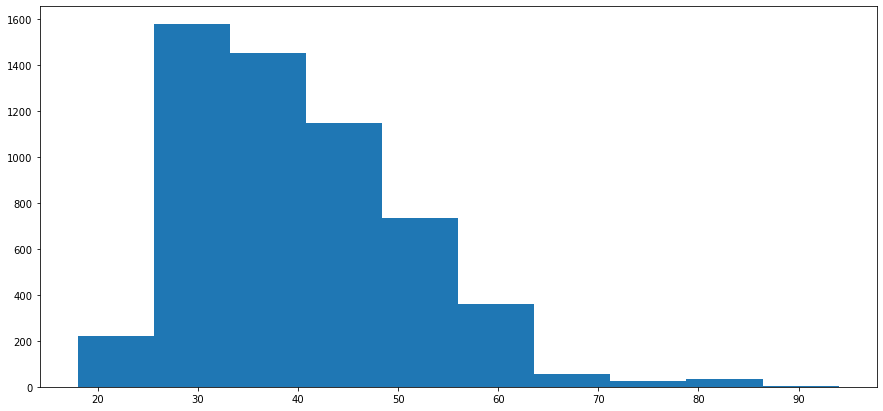

In [9]:
cust_age_values = df[~df['custAge'].isna()]['custAge'].values
print('Skewness Rate: {}'.format(skew(cust_age_values)))
pyplot.hist(cust_age_values)
pyplot.plot()

### Boxplot - Target Correlation

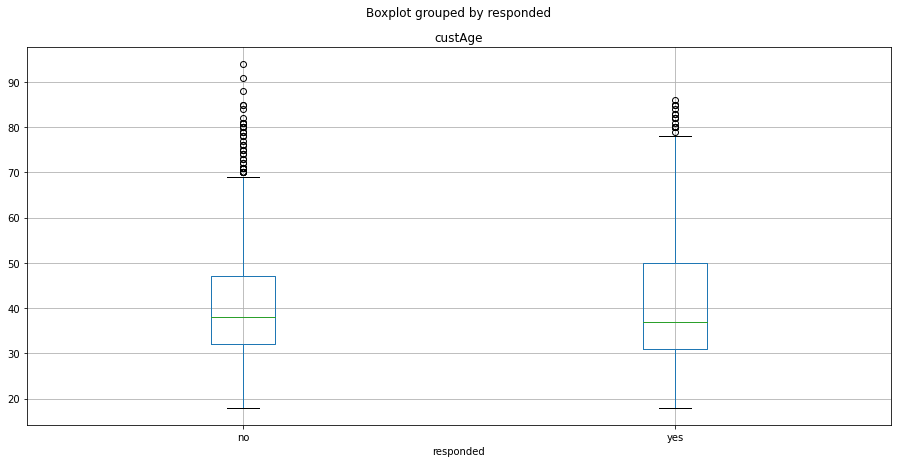

In [10]:
df[['custAge','responded']].boxplot(['custAge'], 'responded')
pyplot.show()

## Schooling

In [11]:
df['schooling'].value_counts()

university.degree      1554
high.school            1216
basic.9y                784
professional.course     664
basic.4y                534
basic.6y                275
unknown                 231
illiterate                1
Name: schooling, dtype: int64

## Day of Week

In [12]:
df['day_of_week'].value_counts()

mon    1441
thu    1379
tue    1341
wed    1295
fri    1247
Name: day_of_week, dtype: int64

## Resolve Missing Values

In [13]:
def resolve_missing_values(df, th=70):
    df_missing = df.copy()

    age_avg = df_missing[df_missing['custAge'] < th]['custAge'].median()
    df_missing['custAge'] = df_missing['custAge'].fillna(age_avg)

    df_missing['schooling'] = df_missing['schooling'].fillna('empty')
    df_missing['day_of_week'] = df_missing['day_of_week'].fillna('empty')
    
    return df_missing

df_missing = resolve_missing_values(df)
df_missing.isnull().sum()

custAge           0
profession        0
marital           0
schooling         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
pmonths           0
pastEmail         0
responded         0
not_prev_cont     0
is_empty_day      0
dtype: int64

## Isolate Binary Columns

In [14]:
bin_values = df_missing[binary_cols].values
df_binary = pandas.DataFrame(data=bin_values, columns=['not_prev_cont', 'is_empty_day'])

## Isolate Numerical Columns

In [15]:
num_values = df_missing[numerical_cols].values

scaler = StandardScaler().fit(num_values)
df_scaled_num = pandas.DataFrame(data=scaler.transform(num_values))

df_scaled_num.head()

,0,1,2,3,4,5,6,7,8,9,10
0,-0.096978,0.202123,-0.309429,1.675590,-0.356294,-0.563419,0.418252,0.348394,0.202121,-0.641025,-0.286848
1,0.859475,0.202123,-0.459983,-0.164620,-0.356294,-0.563419,0.860089,0.789146,0.202121,0.600533,-0.286848
2,0.668184,0.202123,0.895006,0.268371,-0.356294,-0.563419,0.352591,0.730111,0.202121,0.731952,-0.286848
3,0.859475,0.202123,-0.459983,1.675590,-0.356294,-0.192344,0.860089,0.790292,0.202121,0.600533,-0.286848
4,-1.180959,0.202123,-1.212754,-0.164620,1.578915,0.920881,-0.904526,-1.313738,0.202121,-1.171886,0.505806


## Isolate Categorical Columns

In [16]:
encoder = OneHotEncoder()
encoder.fit(df_missing[categorical_cols])
column_name = encoder.get_feature_names(categorical_cols)

df_features = pandas.DataFrame(
    encoder.transform(df_missing[categorical_cols]).toarray(),
    columns=column_name
)

df_features = df_features.join(df_scaled_num)
df_features = df_features.join(df_binary)

df_features['target'] = df['responded'].values

df_features.head()

,profession_admin.,profession_blue-collar,profession_entrepreneur,profession_housemaid,profession_management,profession_retired,profession_self-employed,profession_services,profession_student,profession_technician,...,4,5,6,7,8,9,10,not_prev_cont,is_empty_day,target
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.356294,-0.563419,0.418252,0.348394,0.202121,-0.641025,-0.286848,1,0,no
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.356294,-0.563419,0.860089,0.789146,0.202121,0.600533,-0.286848,1,0,no
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.356294,-0.563419,0.352591,0.730111,0.202121,0.731952,-0.286848,1,0,no
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.356294,-0.192344,0.860089,0.790292,0.202121,0.600533,-0.286848,1,0,no
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.578915,0.920881,-0.904526,-1.313738,0.202121,-1.171886,0.505806,1,0,no


## Train / Test Split

### Train Dataset

In [17]:
df_data_tra = df_features.sample(frac=0.70, random_state=42)
df_data_tra['target'].value_counts()

no     4585
yes     605
Name: target, dtype: int64

### Test Dataset

In [18]:
df_data_tes = df_features.drop(df_data_tra.index)
df_data_tes['target'].value_counts()

no     1989
yes     235
Name: target, dtype: int64

### Balancing Labels

In [19]:
X_tra = df_data_tra.drop(['target'], axis=1).values
y_tra = df_data_tra[['target']].values

X_tes = df_data_tes.drop(['target'], axis=1).values
y_tes = df_data_tes[['target']].values

oversample = RandomOverSampler(random_state=42)
X_over, y_over = oversample.fit_resample(X_tra, y_tra)

## Auxiliar Plot Functions

### Plot ROC Curve

In [20]:
def plot_roc_curve(classifier, X_tes, y_tes):
    metrics.plot_roc_curve(classifier, X_tes, y_tes)
    pyplot.show()

### Plot Precision Recall Curve

In [21]:
def plot_precision_recall_curve(classifier, X_tes):
    y_scores = classifier.predict_proba(X_tes)[:, 1]
    yn_tes = numpy.where(y_tes == 'yes', 1, 0)

    precisions, recalls, thresholds = metrics.precision_recall_curve(yn_tes, y_scores)

    pyplot.title('Precision and Recall Scores as a function of the decision threshold')
    pyplot.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    pyplot.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    pyplot.ylabel('Score')
    pyplot.xlabel('Decision Threshold')
    pyplot.legend(loc='best')

### Print Model Statistics

In [22]:
def evaluate(classifier, X_tes, th):
    y_prd = ['yes' if x > th else 'no' for x in classifier.predict_proba(X_tes)[:, 1]]
    print(metrics.classification_report(y_tes, y_prd))
    
    return y_prd

### Plot Confusion Matrix

In [23]:
def plot_confusion_matrix(y_tes, y_prd):
    cm = metrics.confusion_matrix(y_tes, y_prd)
    cmd = metrics.ConfusionMatrixDisplay(cm, display_labels=['no','yes'])

    cmd.plot()

    pyplot.xticks(rotation=0)
    pyplot.show()

## Cross Validation

In [24]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

## Model 1: Random Forest

In [25]:
param_search = { 
    'n_estimators': [500, 1000],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [4, 5, 6, 7, 8, 10],
    'criterion': ['gini', 'entropy']
}

rf_rss = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_search,
    n_iter=5,
    scoring='f1_micro',
    n_jobs=4,
    cv=kfold,
    verbose=3,
    random_state=42
)

rf_rss.fit(X_over, y_over)
rf_classifier = rf_rss.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  15 out of  15 | elapsed:   18.8s finished


### ROC Curve

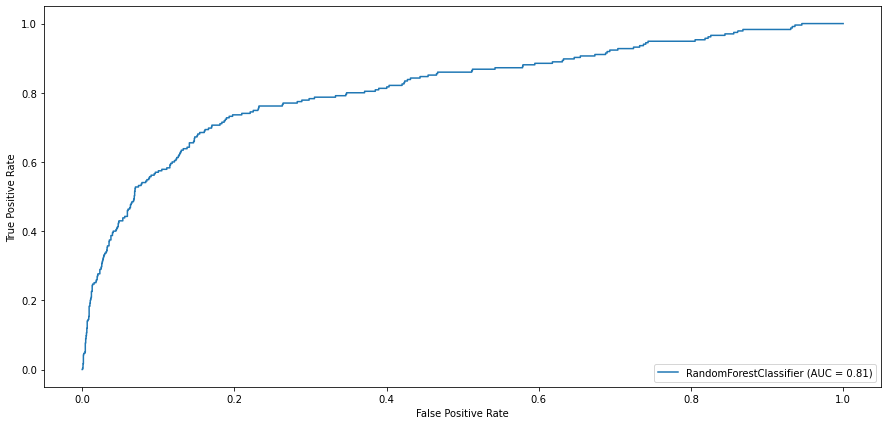

In [26]:
plot_roc_curve(rf_classifier, X_tes, y_tes)

### Precision Recall Curves - Decision Threshold

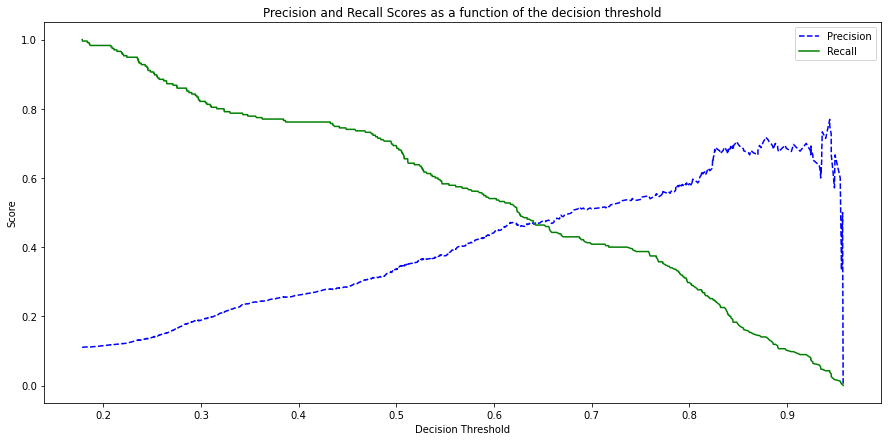

In [27]:
plot_precision_recall_curve(rf_classifier, X_tes)

### Classification Report

In [28]:
rf_y_prd = evaluate(rf_classifier, X_tes, th=0.65)

              precision    recall  f1-score   support

          no       0.94      0.94      0.94      1989
         yes       0.48      0.46      0.47       235

    accuracy                           0.89      2224
   macro avg       0.71      0.70      0.70      2224
weighted avg       0.89      0.89      0.89      2224



### Confusion Matrix

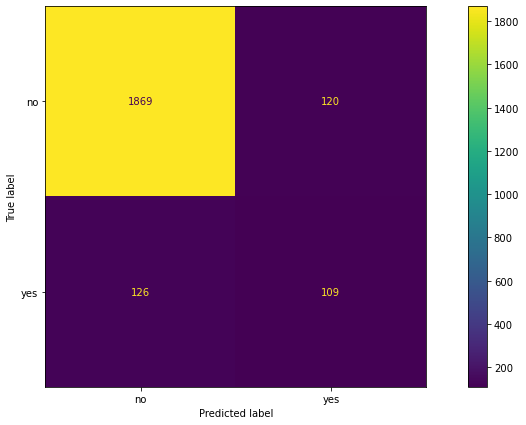

In [29]:
plot_confusion_matrix(y_tes, rf_y_prd)

## Model 2: Multilayer Perceptron

In [30]:
param_search = {
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant', 'adaptive'],
    'early_stopping': [True, False],
    'validation_fraction': [0.1, 0.2],
    'epsilon': [1e-10, 1e-8, 1e-7, 1e-5],
    'momentum': [0.6, 0.7, 0.8, 0.9]
}

nn_rss = RandomizedSearchCV(
    MLPClassifier(random_state=42),
    param_distributions=param_search,
    n_iter=5,
    scoring='f1_micro',
    n_jobs=4,
    cv=kfold,
    verbose=3,
    random_state=42
)

nn_rss.fit(X_over, y_over)
nn_classifier = nn_rss.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  15 out of  15 | elapsed:   25.1s finished


### ROC Curve

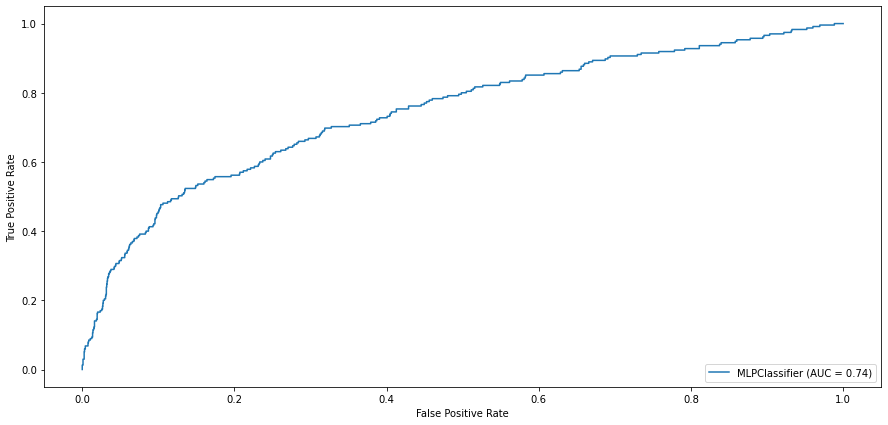

In [31]:
plot_roc_curve(nn_classifier, X_tes, y_tes)

### Precision Recall Curves - Decision Threshold

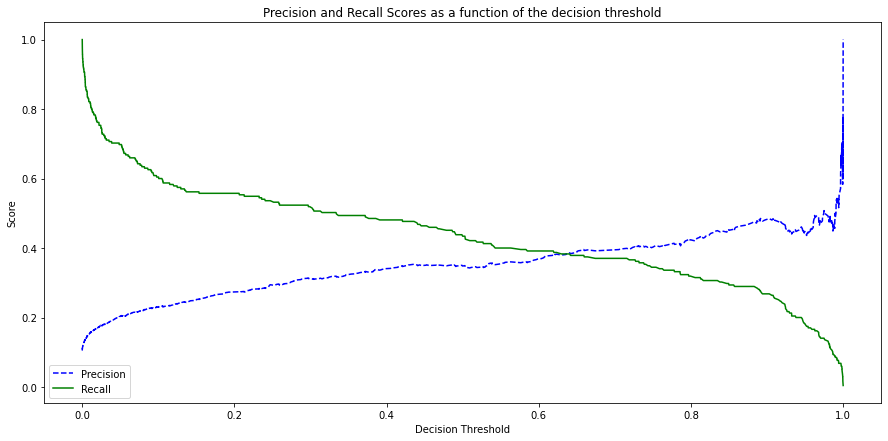

In [32]:
plot_precision_recall_curve(nn_classifier, X_tes)

### Classification Report

In [33]:
nn_y_prd = evaluate(nn_classifier, X_tes, th=0.65)

              precision    recall  f1-score   support

          no       0.93      0.93      0.93      1989
         yes       0.39      0.38      0.38       235

    accuracy                           0.87      2224
   macro avg       0.66      0.65      0.66      2224
weighted avg       0.87      0.87      0.87      2224



### Confusion matrix

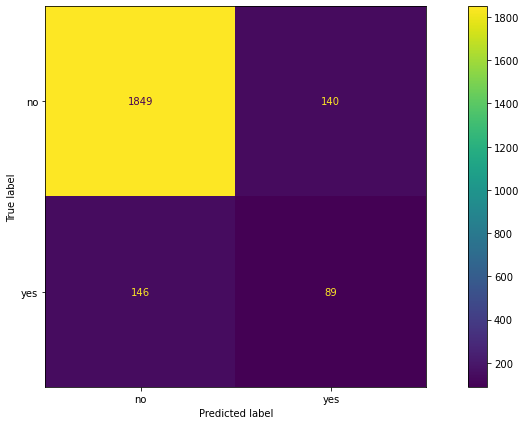

In [34]:
plot_confusion_matrix(y_tes, nn_y_prd)

## Conclusion

Conclusion...

### Fetch Test Dataset

In [35]:
df_resp = pandas.read_csv('marketing_test.csv')
df_resp.head(5)

,Unnamed: 0,custAge,profession,marital,schooling,default,housing,loan,contact,month,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pmonths,pastEmail
0,0,NaN,entrepreneur,married,university.degree,no,yes,no,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,999.0,0
1,1,58.0,entrepreneur,married,university.degree,unknown,no,no,telephone,jun,...,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,999.0,0
2,2,48.0,entrepreneur,married,NaN,no,no,no,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,999.0,0
3,3,35.0,blue-collar,married,NaN,no,yes,no,telephone,jun,...,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1,999.0,0
4,4,39.0,blue-collar,married,basic.6y,no,no,no,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,999.0,0


### Resolve Missing Values

In [36]:
df_resp_msv = resolve_missing_values(df_resp)
df_resp_msv = empty_indicator(df_resp_msv)

df_resp_msv.isnull().sum()

Unnamed: 0        0
custAge           0
profession        0
marital           0
schooling         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
pmonths           0
pastEmail         0
not_prev_cont     0
is_empty_day      0
dtype: int64

### Isolate Binary Columns

In [37]:
bin_values_resp = df_resp_msv[binary_cols].values
df_binary_resp = pandas.DataFrame(data=bin_values_resp, columns=['not_prev_cont','is_empty_day'])

### Isolate Numerical Columns

In [38]:
num_values_resp = df_resp_msv[numerical_cols].values

# use trained scaler
df_scaled_num_resp = pandas.DataFrame(data=scaler.transform(num_values_resp))
df_scaled_num_resp.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.859475,0.202123,-0.459983,-0.272868,-0.356294,-0.192344,0.860089,0.790865,0.202121,0.600533,-0.286848
1,0.859475,0.202123,-0.266413,2.000332,-0.356294,-0.563419,0.860089,0.788572,0.202121,1.546400,-0.286848
2,0.859475,0.202123,-0.459983,0.917856,-0.356294,-0.563419,0.860089,0.789146,0.202121,0.600533,-0.286848
3,0.859475,0.202123,-0.266413,-0.489363,-0.356294,0.549806,0.860089,0.734123,0.202121,1.546400,-0.286848
4,0.859475,0.202123,-0.459983,-0.056372,-0.356294,-0.563419,0.860089,0.789146,0.202121,0.600533,-0.286848


### Isolate Categorical Columns and Predict

In [39]:
df_features_resp = pandas.DataFrame(
    encoder.transform(df_resp_msv[categorical_cols]).toarray(),
    columns=column_name
)

df_features_resp = df_features_resp.join(df_scaled_num_resp)
df_features_resp = df_features_resp.join(df_binary_resp)

labels = rf_classifier.predict_proba(df_features_resp.values)[:, 1]
df_features_resp['label'] = ['yes' if x > 0.65 else 'no' for x in labels]

df_features_resp['id'] = df_resp['Unnamed: 0'].values

df_labeled = df_features_resp[['id','label']]
df_labeled.head()

,id,label
0,0,no
1,1,no
2,2,no
3,3,no
4,4,no


### Save Labeled Records

In [40]:
df_labeled['label'].value_counts()

no     747
yes     77
Name: label, dtype: int64